# pyfantastat — Feature Demo

This notebook walks through every public API surface of **pyfantastat**, a Python library for Italian fantasy football (Fantacalcio) league analysis.

**Sections**
1. Loading a calendar from Excel
2. Building a Championship
3. Generating and displaying the ranking
4. Match result deep-dive
5. Analytics (W/D/L, SoS, scoring days, close matches, prizes)
6. Statistics module
7. What-if calendar analysis
8. Monte Carlo ranking simulation
9. Formazioni — Lineup Parsing & Analytics

## Setup

Install optional visualisation libraries if needed:

In [1]:
# Uncomment to install:
# import subprocess, sys
# subprocess.run([sys.executable, '-m', 'pip', 'install', 'matplotlib', 'pandas', 'seaborn'], check=True)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)

---
## 1 · Loading a Calendar

Fantacalcio leagues are typically exported as Excel workbooks. `load_calendar_xlsx` parses the standard layout and returns a `CalendarData` dataclass.

The notebook first tries to load a real league file; if it's not found a synthetic eight-team dataset is used so every section still runs.

In [ ]:
from pyfantastat import load_calendar_xlsx, CalendarData

# Replace with the path to your own Fantacalcio calendar Excel file
XLSX_PATH = Path('..') / 'your_calendar.xlsx'

try:
    data: CalendarData = load_calendar_xlsx(XLSX_PATH)
    print(f'Loaded: {XLSX_PATH.name}')
except FileNotFoundError:
    print('Real file not found — using synthetic data.')
    import random, collections
    rng = random.Random(0)
    _names = [f'Team{i}' for i in range(8)]
    _n_rounds = 7
    _pts   = {n: [round(rng.uniform(55, 100), 1) for _ in range(_n_rounds)] for n in _names}
    _cal   = []
    for rnd in range(7):
        shuffled = list(range(8)); rng.shuffle(shuffled)
        _cal.append([[shuffled[i], shuffled[i+1]] for i in range(0, 8, 2)])
    data = CalendarData(
        league_name='Synthetic League',
        team_names=_names, user_names=_names,
        team_points=_pts, match_count=_n_rounds,
        calendar=_cal, current_matchday=_n_rounds,
        first_matchday_serie_a=1, last_matchday_serie_a=_n_rounds,
    )

print(f'League  : {data.league_name or "(unnamed)"}')
print(f'Teams   : {len(data.team_names)}')
print(f'Matchdays played : {data.current_matchday} / {data.match_count}')

In [3]:
# Fantapoints per team per matchday
played = data.current_matchday or data.match_count
df_pts = pd.DataFrame(
    {name: pts[:played] for name, pts in data.team_points.items()},
    index=pd.RangeIndex(1, played + 1, name='Matchday'),
).T
df_pts.columns.name = 'Matchday'
df_pts.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.1f}')

Matchday,1,2,3,4,5,6,7
Team0,93.0,89.1,73.9,66.7,78.0,73.2,90.3
Team1,68.6,76.4,81.3,95.9,77.7,67.7,89.0
Team2,82.8,66.3,95.9,99.2,91.5,95.6,69.0
Team3,87.8,95.4,85.8,76.2,59.5,74.5,82.5
Team4,96.1,98.5,76.5,93.9,66.7,91.2,79.7
Team5,55.6,87.4,72.9,92.1,85.1,55.1,77.2
Team6,94.0,66.0,69.6,94.2,63.6,80.5,65.7
Team7,98.5,91.1,75.2,58.6,69.4,77.9,97.0


---
## 2 · Building a Championship

`Championship.from_calendar_data()` is the one-liner factory — it builds `Team` objects, populates their score histories, and attaches the calendar in a single call.

**Tiebreaker criteria (`card_order`)** are applied in order when two or more teams finish on equal league points. Available options:
- `"Punti"` — league points (always effective as a baseline)
- `"Somma punti totale"` — total fantapoints scored across the season
- `"Classifica avulsa"` — head-to-head points between tied teams
- `"Differenza reti"` — goal difference
- `"Gol fatti"` / `"Gol subiti"` — goals scored / conceded

In [4]:
from pyfantastat import Championship

TIEBREAKERS = ['Punti', 'Classifica avulsa', 'Differenza reti', 'Somma punti totale']

ch = Championship.from_calendar_data(
    data,
    card_order=TIEBREAKERS,
)

print(f'Competition type : {ch.competition_type}')
print(f'Goal threshold   : {ch.goal_threshold or 5} pts  ')
print(f'Interval mode    : {ch.interval}')
print(f'Teams registered : {len(ch.teams)}')

Competition type : Standard
Goal threshold   : 5 pts  
Interval mode    : False
Teams registered : 8


> **Manual construction** (alternative to the factory):
> ```python
> from pyfantastat import Team, Championship
> teams = []
> for name, user in zip(data.team_names, data.user_names):
>     t = Team(name, user)
>     t.add_fanta_pts_scored(data.team_points[name])
>     teams.append(t)
> ch = Championship(teams, card_order=TIEBREAKERS)
> ch.set_calendar(data.calendar)
> ```

---
## 3 · Generating and Displaying the Ranking

`generate_ranking()` replays every match in the calendar, converts fantapoints to goals using the configured thresholds, and awards 3/1/0 points per result. It is **idempotent** — safe to call multiple times.

In [5]:
ch.generate_ranking()
sorted_idx, warning = ch.sort_ranking()

if warning:
    print('⚠', warning)

rows = []
for rank, idx in enumerate(sorted_idx, start=1):
    t = ch.teams[idx]
    rows.append({
        'Rank': rank,
        'Team': t.team_name,
        'Manager': t.user_name,
        'Pts': int(ch.ranking[idx]),
        'G+': t.goals_scored,
        'G-': t.goals_conceded,
        'G±': t.goals_scored - t.goals_conceded,
        'Fpt': round(sum(t.fanta_pts_scored), 1),
    })

df_rank = pd.DataFrame(rows).set_index('Rank')
df_rank

,Team,Manager,Pts,G+,G-,G±,Fpt
Rank,,,,,,,
1,Team4,Team4,18,33.0,16.0,17.0,602.6
2,Team2,Team2,15,31.0,15.0,16.0,600.3
3,Team7,Team7,13,26.0,28.0,-2.0,567.7
4,Team0,Team0,8,24.0,24.0,0.0,564.2
5,Team1,Team1,8,23.0,31.0,-8.0,556.6
6,Team5,Team5,7,20.0,29.0,-9.0,525.4
7,Team6,Team6,6,17.0,28.0,-11.0,533.6
8,Team3,Team3,6,24.0,27.0,-3.0,561.7


---
## 4 · Match Result Deep-Dive

Goals are awarded by counting how many thresholds a team's fantapoints cross. With the default 5-point gap the thresholds are 66, 71, 76, 81, 86, 91, 96.

- **Result code 1** → team A wins
- **Result code 2** → team B wins
- **Result code 0** → draw

In [6]:
# Single match from the calendar
match = ch.calendar[0][0]
result, goals = ch.match_result(match, matchday=0)
ta, tb = ch.teams[match[0]].team_name, ch.teams[match[1]].team_name
label = {1: f'{ta} wins', 2: f'{tb} wins', 0: 'Draw'}[result]
print(f'Match: {ta} vs {tb}')
print(f'Fantapoints: {ch.teams[match[0]].fanta_pts_scored[0]:.1f}  vs  {ch.teams[match[1]].fanta_pts_scored[0]:.1f}')
print(f'Goals: {int(goals[0])}  -  {int(goals[1])}')
print(f'Result: {label} (code {result})')

Match: Team3 vs Team7
Fantapoints: 87.8  vs  98.5
Goals: 5  -  7
Result: Team7 wins (code 2)


In [7]:
# Standalone calculation without a calendar
result2, goals2 = ch.match_result_from_points(78.5, 72.0)
print(f'78.5 vs 72.0 → goals {int(goals2[0])}-{int(goals2[1])}, result code {result2}')

78.5 vs 72.0 → goals 3-2, result code 1


In [8]:
# Full results grid for all played matchdays
rows_res = []
for day_idx, day in enumerate(ch.calendar):
    for match in day:
        res, g = ch.match_result(match, day_idx)
        ta_name = ch.teams[match[0]].team_name
        tb_name = ch.teams[match[1]].team_name
        pts_a = ch.teams[match[0]].fanta_pts_scored[day_idx]
        pts_b = ch.teams[match[1]].fanta_pts_scored[day_idx]
        outcome = {1: 'W/L', 2: 'L/W', 0: 'D/D'}[res]
        rows_res.append({
            'Round': day_idx + 1,
            'Home': ta_name,
            'Fpt H': pts_a,
            'Fpt A': pts_b,
            'Away': tb_name,
            'Goals': f'{int(g[0])}-{int(g[1])}',
            'Result': outcome,
        })

pd.DataFrame(rows_res)

,Round,Home,Fpt H,Fpt A,Away,Goals,Result
0,1,Team3,87.8,98.5,Team7,5-7,L/W
1,1,Team5,55.6,93.0,Team0,0-6,L/W
2,1,Team6,94.0,96.1,Team4,6-7,L/W
3,1,Team2,82.8,68.6,Team1,4-1,W/L
4,2,Team7,91.1,89.1,Team0,6-5,W/L
5,2,Team1,76.4,66.3,Team2,3-1,W/L
6,2,Team5,87.4,98.5,Team4,5-7,L/W
7,2,Team6,66.0,95.4,Team3,1-6,L/W
8,3,Team5,72.9,85.8,Team3,2-4,L/W
9,3,Team0,73.9,75.2,Team7,2-2,D/D


---
## 5 · Analytics

All analytics methods require `generate_ranking()` to have been called first (it populates `goals_scored` / `goals_conceded` on each team).

### 5.1 Wins, Draws & Losses

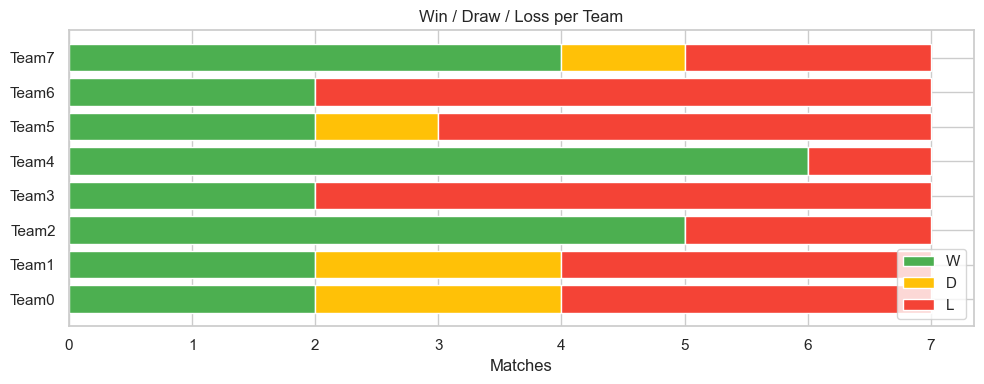

,W,D,L
Team0,2,2,3
Team1,2,2,3
Team2,5,0,2
Team3,2,0,5
Team4,6,0,1
Team5,2,1,4
Team6,2,0,5
Team7,4,1,2


In [9]:
wdl = ch.get_wins_draws_losses()
df_wdl = pd.DataFrame(wdl).T[['W', 'D', 'L']]

fig, ax = plt.subplots(figsize=(10, 4))
left = np.zeros(len(df_wdl))
colours = {'W': '#4CAF50', 'D': '#FFC107', 'L': '#F44336'}
for col in ['W', 'D', 'L']:
    ax.barh(df_wdl.index, df_wdl[col], left=left, label=col, color=colours[col])
    left += df_wdl[col].values
ax.set_xlabel('Matches')
ax.set_title('Win / Draw / Loss per Team')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
df_wdl

### 5.2 Strength of Schedule

Average fantapoints scored by each team's opponents — a high value means facing tougher competition.

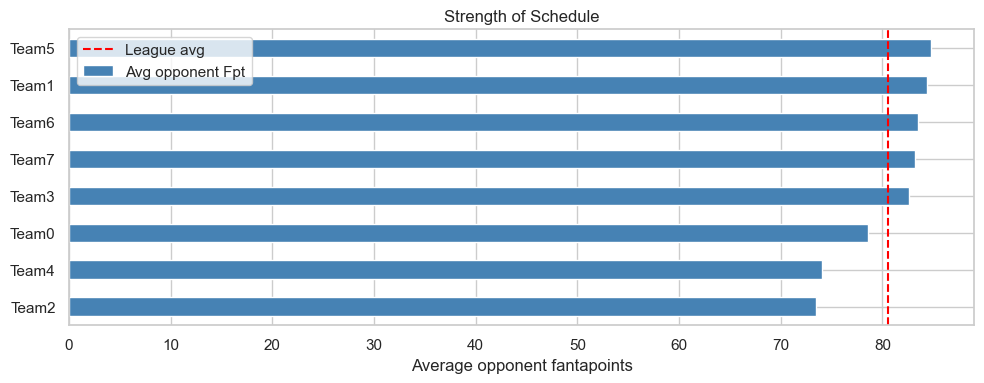

In [10]:
sos = {ch.teams[i].team_name: ch.strength_of_schedule(i) for i in range(len(ch.teams))}
df_sos = pd.Series(sos, name='Avg opponent Fpt').sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
df_sos.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Average opponent fantapoints')
ax.set_title('Strength of Schedule')
ax.axvline(df_sos.mean(), color='red', linestyle='--', label='League avg')
ax.legend()
plt.tight_layout()
plt.show()

### 5.3 Total Fantapoints Ranking

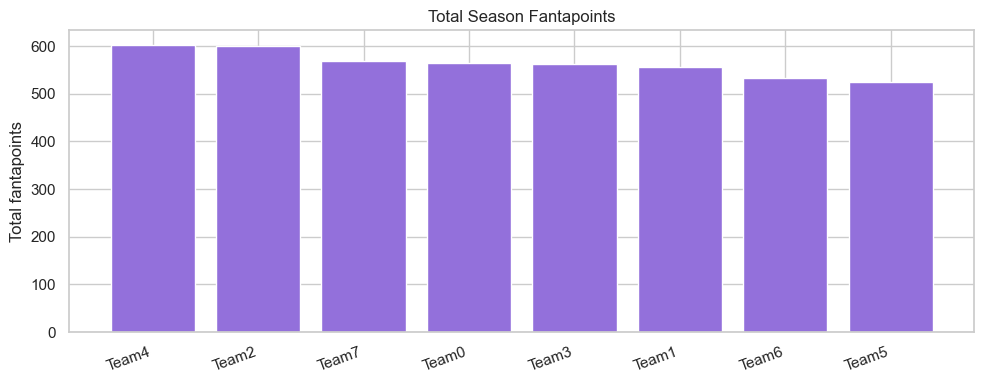

In [11]:
fpt_rank = ch.total_fpt_ranking()
names_fpt, totals = zip(*fpt_rank)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(names_fpt, totals, color='mediumpurple')
ax.set_ylabel('Total fantapoints')
ax.set_title('Total Season Fantapoints')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 5.4 Highest & Lowest Scoring Matchdays

Combined fantapoints across all matches played on each round.

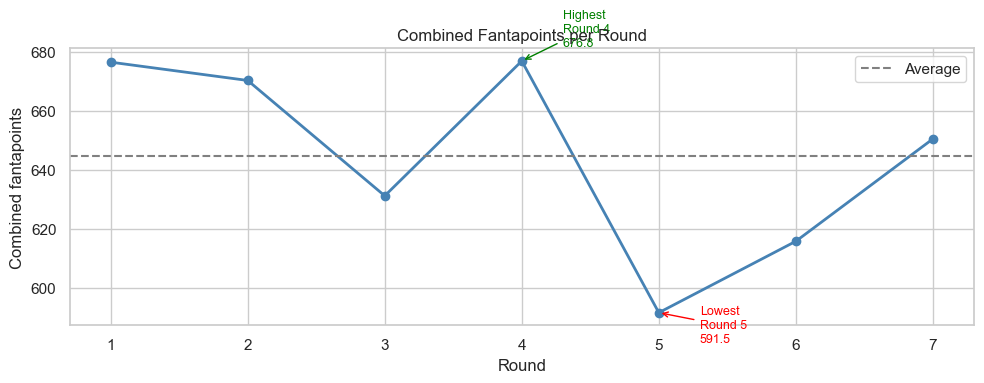

In [12]:
lo_day, lo_score = ch.lowest_scoring_day()
hi_day, hi_score = ch.highest_scoring_day()

# Build per-round combined scores
day_scores = []
for day_idx, day in enumerate(ch.calendar):
    total = sum(
        ch.teams[m[0]].fanta_pts_scored[day_idx] + ch.teams[m[1]].fanta_pts_scored[day_idx]
        for m in day
    )
    day_scores.append(total)

fig, ax = plt.subplots(figsize=(10, 4))
x = range(1, len(day_scores) + 1)
ax.plot(x, day_scores, marker='o', color='steelblue', linewidth=2)
ax.axhline(np.mean(day_scores), color='grey', linestyle='--', label='Average')
ax.annotate(f'Highest\nRound {hi_day+1}\n{hi_score:.1f}',
            xy=(hi_day+1, hi_score), xytext=(hi_day+1.3, hi_score+5),
            arrowprops=dict(arrowstyle='->', color='green'), color='green', fontsize=9)
ax.annotate(f'Lowest\nRound {lo_day+1}\n{lo_score:.1f}',
            xy=(lo_day+1, lo_score), xytext=(lo_day+1.3, lo_score-10),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax.set_xlabel('Round')
ax.set_ylabel('Combined fantapoints')
ax.set_title('Combined Fantapoints per Round')
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Close Matches & Close Draws

A match is **close** when both teams score ≥ 66 fantapoints and the difference between them is ≤ 3 points. A **close draw** is a close match that also ends level on goals.

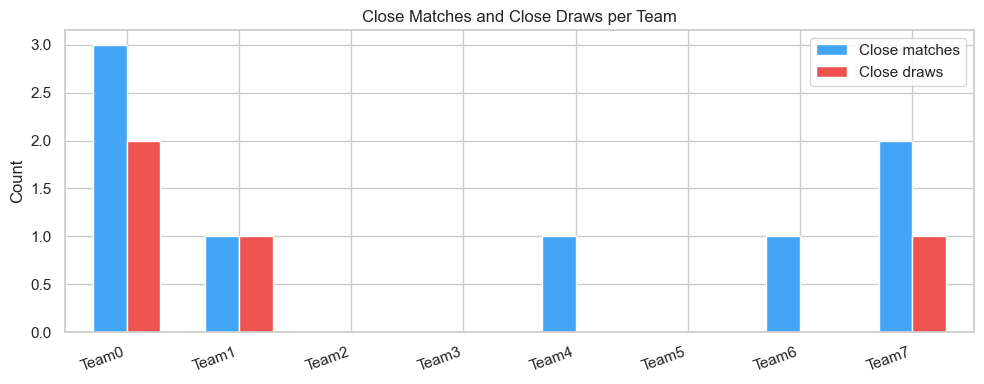

In [13]:
close = ch.number_close_matches()
draws = ch.close_draws()

df_close = pd.DataFrame({'Close matches': close, 'Close draws': draws})

fig, ax = plt.subplots(figsize=(10, 4))
df_close.plot.bar(ax=ax, color=['#42A5F5', '#EF5350'], width=0.6)
ax.set_ylabel('Count')
ax.set_title('Close Matches and Close Draws per Team')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 5.6 Prizes

Best and worst individual performances across all matchdays.

In [14]:
p = ch.prizes()
hi, lo = p['highest'], p['lowest']
print('🏆  Best performance')
print(f'   Team     : {hi["team_name"]}')
print(f'   Matchday : Round {hi["matchday"] + 1}')
print(f'   Points   : {hi["points"]}')
print()
print('😬  Worst performance')
print(f'   Team     : {lo["team_name"]}')
print(f'   Matchday : Round {lo["matchday"] + 1}')
print(f'   Points   : {lo["points"]}')

🏆  Best performance
   Team     : Team2
   Matchday : Round 4
   Points   : 99.2

😬  Worst performance
   Team     : Team5
   Matchday : Round 6
   Points   : 55.1


---
## 6 · Statistics Module

Pure numeric utilities (`mean`, `std`, `median`, `pearson_correlation`) plus domain-aware helpers that work directly on `Team` objects.

In [15]:
from pyfantastat import mean, std, median, pearson_correlation
from pyfantastat.statistics import team_scoring_stats, scoring_correlation

# Pick a reference team
ref = ch.teams[0]
print(f'Team: {ref.team_name}')
print(f'  mean   : {mean(ref.fanta_pts_scored):.2f}')
print(f'  std    : {std(ref.fanta_pts_scored):.2f}')
print(f'  median : {median(ref.fanta_pts_scored):.2f}')

Team: Team0
  mean   : 80.60
  std    : 9.41
  median : 78.00


In [16]:
# team_scoring_stats — all three in one call
rows_stats = []
for t in ch.teams:
    s = team_scoring_stats(t)
    rows_stats.append({'Team': t.team_name, **{k: round(v, 2) for k, v in s.items()}})

pd.DataFrame(rows_stats).set_index('Team')

,mean,std,median
Team,,,
Team0,80.60,9.41,78.0
Team1,79.51,9.51,77.7
Team2,85.76,12.43,91.5
Team3,80.24,10.71,82.5
Team4,86.09,11.02,91.2
Team5,75.06,13.78,77.2
Team6,76.23,12.40,69.6
Team7,81.10,13.86,77.9


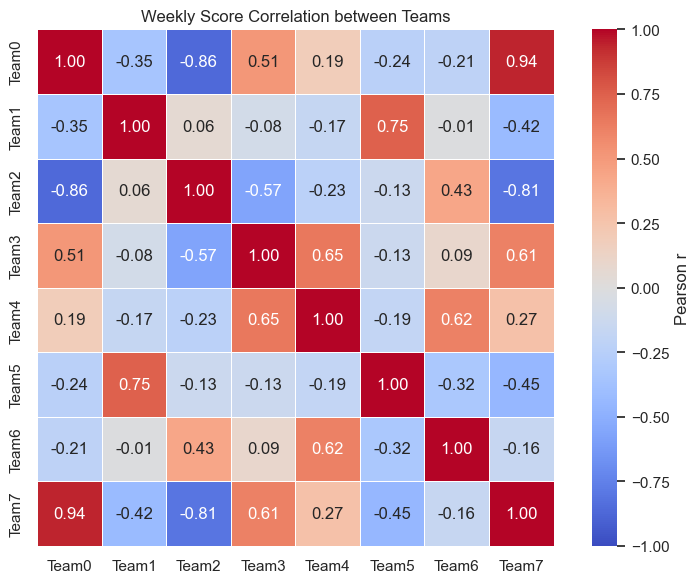

In [17]:
# Pairwise Pearson correlation matrix
names = [t.team_name for t in ch.teams]
n = len(ch.teams)
corr_mat = np.zeros((n, n))
played = ch.current_matchday
for i in range(n):
    for j in range(n):
        if i == j:
            corr_mat[i, j] = 1.0
        elif i < j:
            c = scoring_correlation(ch.teams[i], ch.teams[j], n_matchdays=played)
            corr_mat[i, j] = corr_mat[j, i] = c

df_corr = pd.DataFrame(corr_mat, index=names, columns=names)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
ax.set_title('Weekly Score Correlation between Teams')
plt.tight_layout()
plt.show()

---
## 7 · What-If Calendar Analysis

`what_if_calendar(team_a_idx, team_b_idx)` asks: *how many league points would team A have accumulated if it had played team B's opponents instead of its own?*

It re-runs every matchday using team A's actual fantapoints against whichever team B faced that day.

In [18]:
# Single pair example
a_idx, b_idx = sorted_idx[0], sorted_idx[-1]  # 1st vs last place
actual, what_if = ch.what_if_calendar(a_idx, b_idx)
ta_name, tb_name = ch.teams[a_idx].team_name, ch.teams[b_idx].team_name
print(f'{ta_name} actual points       : {actual}')
print(f'{ta_name} on {tb_name}⁻¹ schedule : {what_if}')
delta = what_if - actual
sign = '+' if delta >= 0 else ''
print(f'Difference                    : {sign}{delta} pts')

Team4 actual points       : 18
Team4 on Team3⁻¹ schedule : 12
Difference                    : -6 pts


In [19]:
# Full what-if matrix
n = len(ch.teams)
wi_mat = np.zeros((n, n), dtype=int)
for i in range(n):
    for j in range(n):
        if i != j:
            _, wi = ch.what_if_calendar(i, j)
            wi_mat[i, j] = wi
        else:
            wi_mat[i, j] = int(ch.ranking[i])

names = [t.team_name for t in ch.teams]
df_wi = pd.DataFrame(wi_mat, index=names, columns=names)
df_wi.index.name = 'Team A'
df_wi.columns.name = "On Team B's schedule"
df_wi.style.background_gradient(cmap='RdYlGn', axis=None)

On Team B's schedule,Team0,Team1,Team2,Team3,Team4,Team5,Team6,Team7
Team A,,,,,,,,
Team0,8,7,14,7,14,6,7,11
Team1,10,8,12,10,11,6,9,10
Team2,13,10,15,13,15,13,10,10
Team3,10,9,15,6,14,5,6,9
Team4,12,9,16,12,18,11,12,14
Team5,4,4,13,8,10,7,7,6
Team6,6,5,8,3,9,5,6,5
Team7,11,9,13,8,16,9,9,13


---
## 8 · Monte Carlo Ranking Simulation

`MonteCarloSimulator` estimates the probability that each team finishes in each position by simulating thousands of seasons. Each simulated season randomly draws a calendar from a pre-computed pool (included in the package for 8, 10, or 12 teams) and replays matches using the teams' actual historical fantapoints.

The simulation stops early when the rank-probability matrix stabilises (`patience` consecutive checkpoints with max change < `tol`).

In [20]:
from pyfantastat.monte_carlo import MonteCarloSimulator

sim = MonteCarloSimulator(
    ch,
    n_iterations=50_000,
    batch=10_000,
    patience=3,
    tol=0.01,
    seed=42,
)
result = sim.run()

print(f'Seasons simulated : {result.iterations_run:,}')
print(f'Converged early   : {result.converged}')

Seasons simulated : 40,000
Converged early   : True


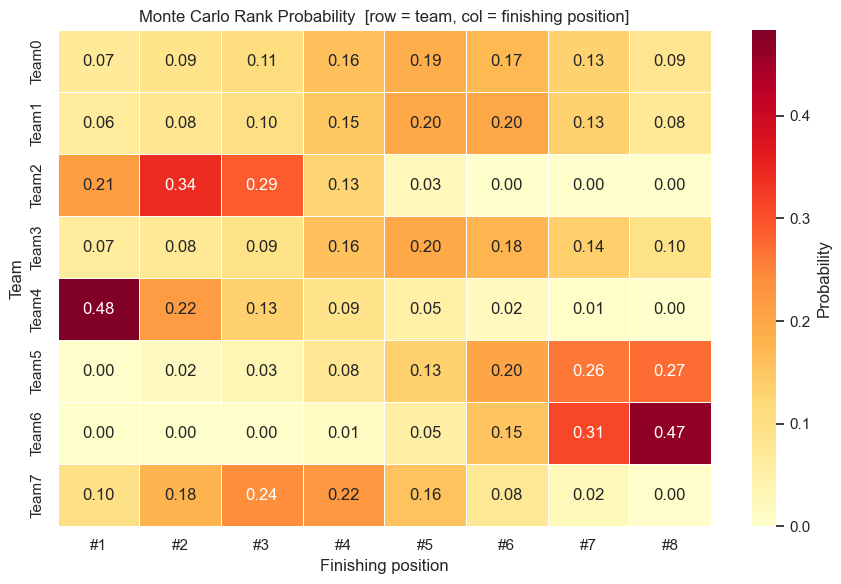

In [21]:
# Rank probability heatmap
names = [t.team_name for t in ch.teams]
rank_labels = [f'#{r}' for r in range(1, len(names) + 1)]

df_rp = pd.DataFrame(
    result.rank_probabilities,
    index=names,
    columns=rank_labels,
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    df_rp, annot=True, fmt='.2f', cmap='YlOrRd',
    vmin=0, vmax=df_rp.values.max(), ax=ax, linewidths=0.5,
    cbar_kws={'label': 'Probability'},
)
ax.set_title('Monte Carlo Rank Probability  [row = team, col = finishing position]')
ax.set_xlabel('Finishing position')
ax.set_ylabel('Team')
plt.tight_layout()
plt.show()

In [22]:
# Expected league points per team
df_ep = pd.DataFrame({
    'Team': names,
    'Expected points': result.expected_points.round(2),
    'P(finish 1st)': result.rank_probabilities[:, 0].round(4),
}).sort_values('Expected points', ascending=False).reset_index(drop=True)
df_ep.index += 1
df_ep.index.name = 'MC Rank'
df_ep

,Team,Expected points,P(finish 1st)
MC Rank,,,
1,Team4,13.87,0.4833
2,Team2,13.14,0.2140
3,Team7,11.55,0.0978
4,Team1,9.83,0.0645
5,Team0,9.58,0.0714
6,Team3,9.58,0.0657
7,Team5,7.45,0.0034
8,Team6,5.73,0.0000


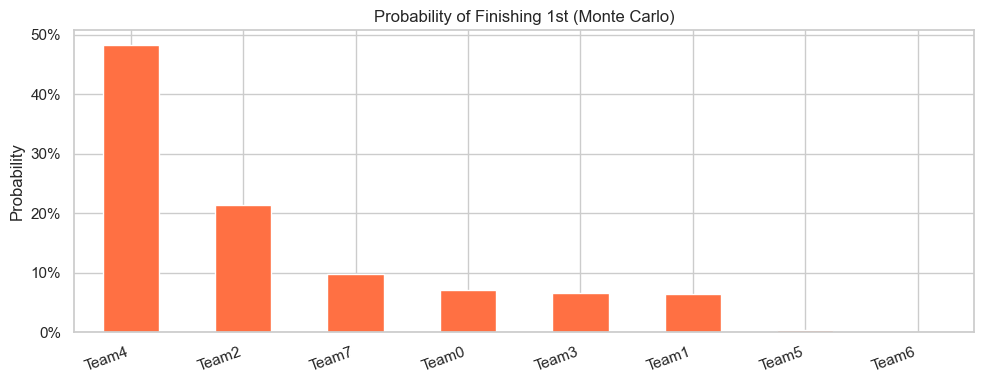

In [23]:
# P(finish 1st) bar chart
p1 = pd.Series(
    result.rank_probabilities[:, 0],
    index=names,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
p1.plot.bar(ax=ax, color='#FF7043')
ax.set_ylabel('Probability')
ax.set_title('Probability of Finishing 1st (Monte Carlo)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

---
## 9 · Formazioni — Lineup Parsing & Analytics

The **Formazioni** pipeline ingests per-matchday lineup Excel files produced by the Fantacalcio platform and exposes four key capabilities:

| Function | Description |
|---|---|
| `load_formazioni_xlsx(path)` | Parse a single matchday file → `FormazioniMatchday` |
| `load_formazioni_dir(dir_path)` | Parse all `.xlsx` files in a directory → `{giornata: FormazioniMatchday}` |
| `build_team_rosters(data)` | Aggregate matchdays into per-team player histories → `{team_name: TeamRoster}` |
| `player_scoring_stats(record)` | Mean/std voto & fantavoto for one player |
| `validate_formazioni(data, calendar_data)` | Cross-check Formazioni totals against the calendar |
| `top_formation(roster)` | Bayesian EFV best-11 selection across all 7 standard formations |

### 9.1 Loading Formazioni Data

Point `load_formazioni_dir` at a folder containing one `.xlsx` file per matchday.  
Each file must have `"Giornata N"` in the first five rows of column A.

The cell falls back to building a tiny synthetic dataset (2 teams, 3 matchdays) when no real files are available.

In [24]:
from pathlib import Path
from pyfantastat import (
    load_formazioni_xlsx, load_formazioni_dir,
    build_team_rosters, player_scoring_stats,
    validate_formazioni, top_formation,
    FormazioniMatchday, FormazioniTeam, FormazioniPlayer,
)

FORM_DIR = Path('..') / 'Formazioni'

if FORM_DIR.is_dir():
    form_data = load_formazioni_dir(FORM_DIR)
    print(f'Loaded {len(form_data)} matchday file(s) from {FORM_DIR}')
else:
    form_data = {}

if not form_data:
    print('No Formazioni files found — using synthetic data.')
    import random
    rng = random.Random(1)
    roles = ['P'] + ['D']*4 + ['C']*4 + ['A']*3
    for g in range(1, 4):
        teams_in_day = []
        for team_name in (data.team_names[:2] if len(data.team_names) >= 2 else ['Team0', 'Team1']):
            players = [
                FormazioniPlayer(
                    name=f'Player{i}',
                    ruolo=roles[i],
                    voto=round(rng.uniform(5, 8), 2),
                    fantavoto=round(rng.uniform(4, 10), 2),
                )
                for i in range(11)
            ]
            totale = round(sum(p.fantavoto for p in players), 2)
            teams_in_day.append(FormazioniTeam(team_name=team_name, totale=totale, players=players))
        form_data[g] = FormazioniMatchday(giornata=g, teams=teams_in_day)
    print(f'Synthetic Formazioni: {len(form_data)} matchdays, {len(form_data[1].teams)} teams each')

for g, md in sorted(form_data.items()):
    print(f'  Giornata {g:2d}: {len(md.teams)} teams')

No Formazioni files found — using synthetic data.
Synthetic Formazioni: 3 matchdays, 2 teams each
  Giornata  1: 2 teams
  Giornata  2: 2 teams
  Giornata  3: 2 teams


### 9.2 Building Team Rosters

In [25]:
rosters = build_team_rosters(form_data)
print(f'Rosters built for {len(rosters)} team(s):\n')
for norm_name, roster in rosters.items():
    n_players = len(roster.players)
    n_matchdays = len({g for rec in roster.players.values() for g in rec.matchdays})
    print(f'  {roster.team_name:<25}  {n_players} players, {n_matchdays} matchday(s) recorded')

Rosters built for 2 team(s):

  Team0                      11 players, 3 matchday(s) recorded
  Team1                      11 players, 3 matchday(s) recorded


### 9.3 Player Scoring Statistics

`player_scoring_stats` returns mean and standard deviation of *voto* and *fantavoto*, excluding matchdays where the player did not participate (voto == fantavoto == 0).

In [26]:
# Show top players by mean fantavoto for the first roster
first_roster = next(iter(rosters.values()))
rows_ps = []
for norm_name, record in first_roster.players.items():
    stats = player_scoring_stats(record)
    appearances = sum(1 for _, fv in record.matchdays.values() if fv > 0)
    rows_ps.append({
        'Player': record.name,
        'Role': record.ruolo or '?',
        'Apps': appearances,
        'μ voto': round(stats['mean_voto'], 2),
        'σ voto': round(stats['std_voto'], 2),
        'μ fantavoto': round(stats['mean_fantavoto'], 2),
        'σ fantavoto': round(stats['std_fantavoto'], 2),
    })

df_ps = (
    pd.DataFrame(rows_ps)
    .sort_values('μ fantavoto', ascending=False)
    .reset_index(drop=True)
)
df_ps.index += 1
df_ps.style.background_gradient(subset=['μ fantavoto'], cmap='YlGn')

,Player,Role,Apps,μ voto,σ voto,μ fantavoto,σ fantavoto
1,Player3,D,3,6.840000,0.720000,8.230000,0.510000
2,Player0,P,3,6.120000,0.750000,8.210000,0.730000
3,Player8,C,3,5.910000,0.430000,7.960000,1.220000
4,Player2,D,3,7.110000,0.440000,7.880000,0.910000
5,Player10,A,3,5.940000,0.640000,7.210000,0.450000
6,Player5,C,3,6.900000,0.430000,6.900000,0.450000
7,Player4,D,3,6.790000,1.070000,6.790000,2.020000
8,Player7,C,3,6.810000,0.430000,6.670000,1.280000
9,Player6,C,3,5.850000,1.020000,6.230000,2.200000
10,Player9,A,3,6.960000,0.670000,6.100000,1.580000


### 9.4 Cross-Validation Against the Calendar

`validate_formazioni` compares each team's `TOTALE` field in the Formazioni files against the fantapoints stored in `CalendarData`.  Only played matchdays are checked.

- **`ok`** — `True` when there are no mismatches, unmatched teams, or missing files.
- **`issues`** — score discrepancies above the tolerance (default 0.5 pts).
- **`unmatched_teams`** — team names in Formazioni not found in the calendar.
- **`missing_matchdays`** — played matchdays with no Formazioni file.

In [27]:
validation = validate_formazioni(form_data, data, tol=0.5)

status = 'PASSED' if validation.ok else 'FAILED'
print(f'Validation: {status}')
print(f'  Issues          : {len(validation.issues)}')
print(f'  Unmatched teams : {len(validation.unmatched_teams)}')
print(f'  Missing matchdays: {len(validation.missing_matchdays)}')

if validation.issues:
    print('\nScore mismatches:')
    df_val = pd.DataFrame([
        {
            'Giornata': v.giornata,
            'Team': v.team_name,
            'Calendar': v.calendar_score,
            'Formazioni': v.formazioni_score,
            'Δ': round(v.delta, 2),
        }
        for v in validation.issues
    ])
    display(df_val)

if validation.unmatched_teams:
    print('\nUnmatched teams:', validation.unmatched_teams)

if validation.missing_matchdays:
    print('\nMissing matchdays:', validation.missing_matchdays)

Validation: FAILED
  Issues          : 5
  Unmatched teams : 0
  Missing matchdays: 4

Score mismatches:


,Giornata,Team,Calendar,Formazioni,Δ
0,1,Team0,93.0,74.25,18.75
1,2,Team0,89.1,80.88,8.22
2,2,Team1,76.4,78.99,2.59
3,3,Team0,73.9,77.50,3.60
4,3,Team1,81.3,72.64,8.66



Missing matchdays: [4, 5, 6, 7]


### 9.5 Top Formation (Bayesian EFV)

`top_formation` selects the best 11-player lineup from a team's roster using **Expected Fantavoto (EFV)** with Bayesian shrinkage (k = 15, ported from *fantakings*).

All seven standard Fantacalcio formations are tested:

| Formation | DEF | MID | ATT |
|---|---|---|---|
| 3-5-2 | 3 | 5 | 2 |
| 3-4-3 | 3 | 4 | 3 |
| 4-5-1 | 4 | 5 | 1 |
| 4-4-2 | 4 | 4 | 2 |
| 4-3-3 | 4 | 3 | 3 |
| 5-3-2 | 5 | 3 | 2 |
| 5-4-1 | 5 | 4 | 1 |

The formation with the highest combined EFV is returned.

In [28]:
for norm_name, roster in rosters.items():
    result = top_formation(roster)
    n_def, n_mid, n_att = result.formation
    print(f'Team          : {roster.team_name}')
    print(f'Best formation: 1-{n_def}-{n_mid}-{n_att}')
    print(f'Total EFV     : {result.total_efv:.2f}')
    print()

    rows_tf = [
        {'#': i + 1, 'Player': p.name, 'Role': p.ruolo, 'EFV': p.efv}
        for i, p in enumerate(result.players)
    ]
    df_tf = pd.DataFrame(rows_tf).set_index('#')
    display(df_tf.style.background_gradient(subset=['EFV'], cmap='YlOrRd'))
    print()

Team          : Team0
Best formation: 1-4-4-2
Total EFV     : 76.57



,Player,Role,EFV
#,,,
1,Player0,P,7.243400
2,Player3,D,7.260400
3,Player2,D,7.201500
4,Player4,D,7.019300
5,Player1,D,6.782100
6,Player8,C,7.108700
7,Player5,C,6.932100
8,Player7,C,6.894900
9,Player6,C,6.821000



Team          : Team1
Best formation: 1-4-4-2
Total EFV     : 73.09



,Player,Role,EFV
#,,,
1,Player0,P,6.778100
2,Player3,D,6.965600
3,Player4,D,6.847200
4,Player1,D,6.648300
5,Player2,D,6.578900
6,Player5,C,6.298200
7,Player7,C,6.178200
8,Player6,C,6.169900
9,Player8,C,6.030400


### 9.6 EFV Visualisation

Bar chart of EFV scores for the selected lineup, grouped by role.

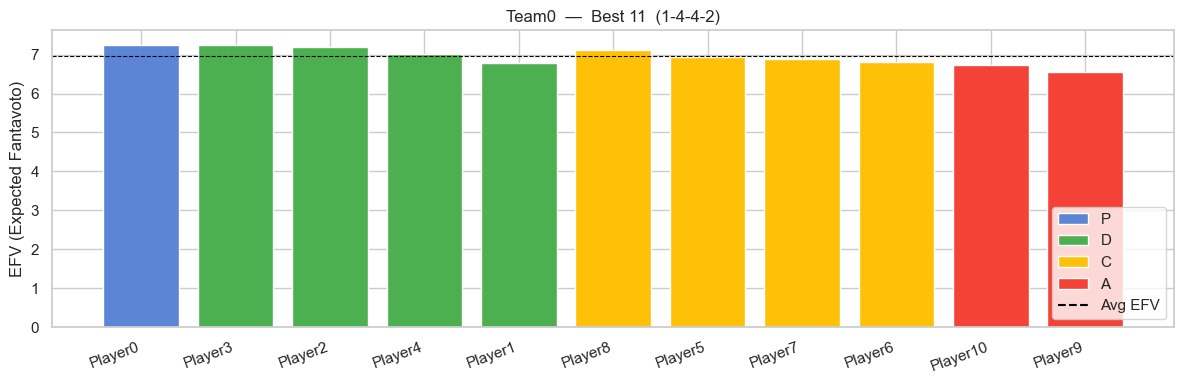

In [29]:
# Use the first team's result for the chart
first_roster = next(iter(rosters.values()))
result = top_formation(first_roster)

role_colours = {'P': '#5C85D6', 'D': '#4CAF50', 'C': '#FFC107', 'A': '#F44336'}
colours = [role_colours.get(p.ruolo, 'grey') for p in result.players]
names_tf = [p.name for p in result.players]
efvs = [p.efv for p in result.players]
n_def, n_mid, n_att = result.formation

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(names_tf, efvs, color=colours)
ax.set_ylabel('EFV (Expected Fantavoto)')
ax.set_title(f'{first_roster.team_name}  —  Best 11  (1-{n_def}-{n_mid}-{n_att})')
ax.axhline(result.total_efv / 11, color='black', linestyle='--', linewidth=0.8, label='Avg EFV')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in role_colours.items()]
legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='--', label='Avg EFV'))
ax.legend(handles=legend_elements, loc='lower right')

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()